# Лабораторная работа №5 — Классификация ЭЭГ моторного воображения (левый / правый кулак)

**Цель.** Обучить нейронную сеть, которая по фрагменту записи ЭЭГ определяет, какой кулак (левый или правый) испытуемый воображал сжимающим.



## 1. Установка зависимостей


In [2]:
# Раскомментировать при первом запуске
!pip install pywavelets tensorflow scikit-learn pillow matplotlib pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Импорт библиотек


In [3]:
import os
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import pywt
from scipy.signal import butter, filtfilt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)
print('PyWavelets:', pywt.__version__)
print('pandas:    ', pd.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
PyWavelets: 1.8.0
pandas:     3.0.3


## 3. Параметры эксперимента


In [ ]:
DATA_DIR   = Path('data')
IMG_DIR    = Path('images')
LEFT_DIR   = IMG_DIR / 'left'
RIGHT_DIR  = IMG_DIR / 'right'
MODEL_PATH = Path('mi_eeg_cnn_model.keras')
for d in (DATA_DIR, LEFT_DIR, RIGHT_DIR):
    d.mkdir(parents=True, exist_ok=True)

SFREQ = 250.0          

BANDPASS_LO    = 8.0
BANDPASS_HI    = 30.0
BANDPASS_ORDER = 4

WAVELET   = 'cmor1.5-1.0'
N_SCALES  = 64
SCALES    = np.arange(1, N_SCALES + 1)

IMG_SIZE   = 96
BATCH_SIZE = 16
EPOCHS     = 20        

BASE_URL   = 'https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/'
TRAIN_DATA_NAME = 'MI-EEG-B9T.csv'
TEST_DATA_NAME  = 'MI-EEG-B9E.csv'
TRAIN_TGT_NAME  = '2class_MI_EEG_train_9.csv'
TEST_TGT_NAME   = '2class_MI_EEG_test_9.csv'

print('Конфигурация загружена.')


Конфигурация загружена.


## 4. Скачивание данных из репозитория



In [5]:
def download_if_missing(filename: str,
                        dest_dir: Path = DATA_DIR,
                        url_base: str = BASE_URL,
                        required: bool = True) -> Path | None:
    """Скачать файл, если его нет локально. Возвращает None, если файла нет и required=False."""
    local_path = dest_dir / filename
    if local_path.exists() and local_path.stat().st_size > 0:
        size_kb = local_path.stat().st_size / 1024
        print(f'  ✓ {filename} уже есть ({size_kb:.1f} КБ)')
        return local_path
    url = url_base + filename
    print(f'  ⬇  Скачиваем {filename} ...', end=' ', flush=True)
    try:
        urllib.request.urlretrieve(url, local_path)
        size_kb = local_path.stat().st_size / 1024
        print(f'готово ({size_kb:.1f} КБ)')
        return local_path
    except Exception as e:
        print(f'не удалось ({e})')
        if local_path.exists():
            local_path.unlink()
        if required:
            raise
        return None


print('Скачиваем CSV-файлы...')
train_path     = download_if_missing(TRAIN_DATA_NAME, required=True)
test_path      = download_if_missing(TEST_DATA_NAME,  required=False)
train_tgt_path = download_if_missing(TRAIN_TGT_NAME,  required=True)
test_tgt_path  = download_if_missing(TEST_TGT_NAME,   required=True)

total_kb = sum(p.stat().st_size for p in DATA_DIR.iterdir()) / 1024
print(f'\nИтого на диске: {total_kb:.1f} КБ')

Скачиваем CSV-файлы...
  ✓ MI-EEG-B9T.csv уже есть (9594.9 КБ)
  ✓ MI-EEG-B9E.csv уже есть (7718.1 КБ)
  ✓ 2class_MI_EEG_train_9.csv уже есть (0.8 КБ)
  ✓ 2class_MI_EEG_test_9.csv уже есть (0.6 КБ)

Итого на диске: 17314.4 КБ


## 5. Загрузка и осмотр данных



In [ ]:
y_train_raw = pd.read_csv(train_tgt_path, header=None).values.ravel().astype(int)
y_test_raw  = pd.read_csv(test_tgt_path,  header=None).values.ravel().astype(int)

print(f'Уникальные значения меток в train: {sorted(set(y_train_raw.tolist()))}')
print(f'Уникальные значения меток в test:  {sorted(set(y_test_raw.tolist()))}')

unique_labels = sorted(set(y_train_raw.tolist()) | set(y_test_raw.tolist()))
assert len(unique_labels) == 2, \
    f'Ожидалось ровно 2 класса, найдено: {unique_labels}'
LEFT_VAL, RIGHT_VAL = unique_labels
print(f'Соответствие: {LEFT_VAL} -> left (0), {RIGHT_VAL} -> right (1)')

y_train = (y_train_raw == RIGHT_VAL).astype(np.int32)
y_test  = (y_test_raw  == RIGHT_VAL).astype(np.int32)

print(f'\nМеток train: {len(y_train)} (left = {(y_train==0).sum()}, right = {(y_train==1).sum()})')
print(f'Меток test:  {len(y_test)}  (left = {(y_test==0).sum()},  right = {(y_test==1).sum()})')

Уникальные значения меток в train: [0, 1]
Уникальные значения меток в test:  [0, 1]
Соответствие: 0 -> left (0), 1 -> right (1)

Меток train: 400 (left = 200, right = 200)
Меток test:  320  (left = 160,  right = 160)


In [ ]:
df_train = pd.read_csv(train_path, header=None)
print(f'train CSV: {df_train.shape}  (строк × отсчётов)')

if test_path is not None:
    df_test = pd.read_csv(test_path, header=None)
    print(f'test CSV:  {df_test.shape}')
else:
    df_test  = df_train.iloc[len(y_train):].reset_index(drop=True)
    df_train = df_train.iloc[:len(y_train)].reset_index(drop=True)

assert df_train.shape[0] == len(y_train), \
    f'train: {df_train.shape[0]} строк vs {len(y_train)} меток'
assert df_test.shape[0] == len(y_test), \
    f'test:  {df_test.shape[0]} строк vs {len(y_test)} меток'

n_samples = df_train.shape[1]
print(f'\nОдна попытка = {n_samples} отсчётов одного канала ЭЭГ '
      f'({n_samples / SFREQ:.2f} с при {SFREQ:.0f} Гц).')


train CSV: (400, 3000)  (строк × отсчётов)
test CSV:  (320, 3000)

Одна попытка = 3000 отсчётов одного канала ЭЭГ (12.00 с при 250 Гц).


In [ ]:
X_train_raw = df_train.values.astype(np.float32)
X_test_raw  = df_test.values.astype(np.float32)
print(f'Сырые: X_train {X_train_raw.shape}, X_test {X_test_raw.shape}')


def butter_bandpass(data: np.ndarray, lo: float, hi: float, fs: float,
                    order: int = BANDPASS_ORDER) -> np.ndarray:
    """Нуль-фазовый полосовой Баттервортовский фильтр, применяется вдоль оси времени."""
    nyq = 0.5 * fs
    b, a = butter(order, [lo / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, data, axis=1)


X_train_filt = butter_bandpass(X_train_raw, BANDPASS_LO, BANDPASS_HI, SFREQ)
X_test_filt  = butter_bandpass(X_test_raw,  BANDPASS_LO, BANDPASS_HI, SFREQ)

scaler = StandardScaler()
X_train_sig = scaler.fit_transform(X_train_filt).astype(np.float32)
X_test_sig  = scaler.transform(X_test_filt).astype(np.float32)

print(f'После фильтра + StandardScaler:')
print(f'  X_train_sig: {X_train_sig.shape}, mean={X_train_sig.mean():+.3e}, std={X_train_sig.std():.3f}')
print(f'  X_test_sig:  {X_test_sig.shape}, mean={X_test_sig.mean():+.3e}, std={X_test_sig.std():.3f}')


Сырые: X_train (400, 3000), X_test (320, 3000)
После фильтра + StandardScaler:
  X_train_sig: (400, 3000), mean=-2.543e-11, std=1.000
  X_test_sig:  (320, 3000), mean=+2.621e-04, std=0.866


### 5.1 Пример сырого сигнала



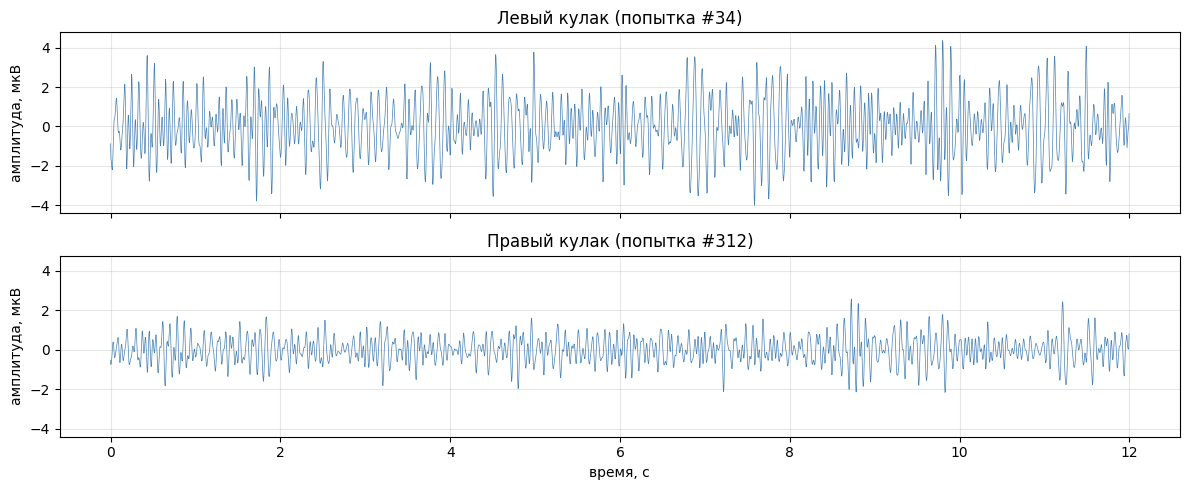

In [9]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, sharey=True)

for ax, label, title in zip(axes, [0, 1], ['Левый кулак', 'Правый кулак']):
    idxs = np.where(y_train == label)[0]
    i = int(rng.choice(idxs))
    t = np.arange(X_train_sig.shape[1]) / SFREQ
    ax.plot(t, X_train_sig[i], lw=0.5, color='steelblue')
    ax.set_title(f'{title} (попытка #{i})')
    ax.set_ylabel('амплитуда, мкВ')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('время, с')
plt.tight_layout()
plt.show()


## 6. Вейвлет-анализ сигнала


In [10]:
def make_scalogram(signal_1d: np.ndarray) -> np.ndarray:
    """CWT 1-D сигнала -> мощность в дБ, форма (N_SCALES, len(signal))."""
    coef, _ = pywt.cwt(signal_1d, SCALES, WAVELET, sampling_period=1.0 / SFREQ)
    power = np.abs(coef) ** 2
    return 10.0 * np.log10(power + 1e-12)


def signal_to_image(signal_1d: np.ndarray, img_size: int = IMG_SIZE) -> Image.Image:
    """Сигнал -> grayscale-скалограмма img_size × img_size (для визуализации)."""
    sg = make_scalogram(signal_1d)
    lo, hi = np.percentile(sg, [2, 98])
    sg = np.clip((sg - lo) / (hi - lo + 1e-9), 0, 1)
    arr = (sg * 255).astype(np.uint8)
    img = Image.fromarray(arr, mode='L')
    return img.resize((img_size, img_size), Image.BILINEAR)


print('Функции CWT и скалограммы определены.')


Функции CWT и скалограммы определены.


In [ ]:
N_EXAMPLES_PER_CLASS = 10

for d in (LEFT_DIR, RIGHT_DIR):
    for f in d.glob('*.png'):
        f.unlink()

rng_save = np.random.default_rng(SEED)
left_idx_all  = np.where(y_train == 0)[0]
right_idx_all = np.where(y_train == 1)[0]
left_pick  = rng_save.choice(left_idx_all,  size=N_EXAMPLES_PER_CLASS, replace=False)
right_pick = rng_save.choice(right_idx_all, size=N_EXAMPLES_PER_CLASS, replace=False)

for i, idx in enumerate(left_pick):
    signal_to_image(X_train_sig[idx]).save(LEFT_DIR / f'left_{i:03d}.png')
for i, idx in enumerate(right_pick):
    signal_to_image(X_train_sig[idx]).save(RIGHT_DIR / f'right_{i:03d}.png')

print(f'  ✓ Сохранено по {N_EXAMPLES_PER_CLASS} примеров скалограмм в {LEFT_DIR} и {RIGHT_DIR}')


  ✓ Сохранено по 10 примеров скалограмм в images\left и images\right


### 6.1 Примеры скалограмм




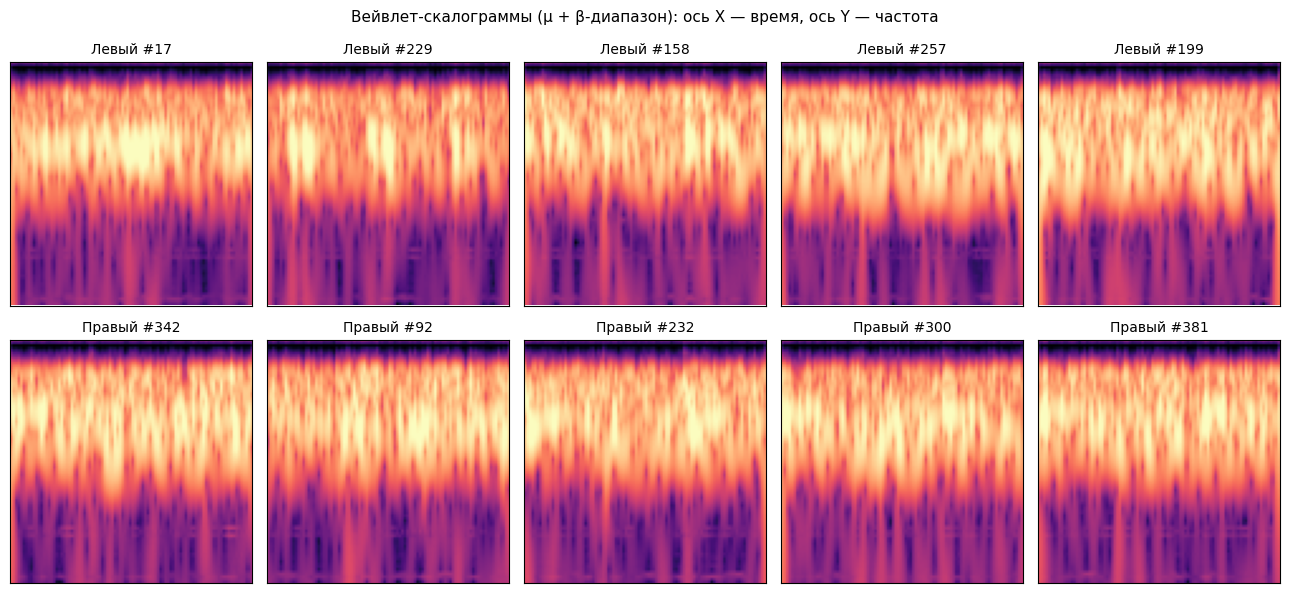

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
rng2 = np.random.default_rng(SEED + 1)

left_idx  = np.where(y_train == 0)[0]
right_idx = np.where(y_train == 1)[0]
left_show  = rng2.choice(left_idx,  size=5, replace=False)
right_show = rng2.choice(right_idx, size=5, replace=False)

for col, (li, ri) in enumerate(zip(left_show, right_show)):
    axes[0, col].imshow(np.asarray(signal_to_image(X_train_sig[li])), cmap='magma', aspect='auto')
    axes[0, col].set_title(f'Левый #{li}', fontsize=10)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].imshow(np.asarray(signal_to_image(X_train_sig[ri])), cmap='magma', aspect='auto')
    axes[1, col].set_title(f'Правый #{ri}', fontsize=10)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle('Вейвлет-скалограммы (μ + β-диапазон): ось X — время, ось Y — частота', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Эксперимент: классификация по вейвлет-изображениям (2-D CNN)


### 7.1 Подготовка изображений для всех попыток


In [ ]:
def signal_to_array(signal_1d: np.ndarray, img_size: int = IMG_SIZE) -> np.ndarray:
    """То же, что signal_to_image, но возвращает numpy-массив (H, W) float32 в [0, 1]."""
    sg = make_scalogram(signal_1d)
    lo, hi = np.percentile(sg, [2, 98])
    sg = np.clip((sg - lo) / (hi - lo + 1e-9), 0, 1)
    arr = (sg * 255).astype(np.uint8)
    img = Image.fromarray(arr, mode='L').resize((img_size, img_size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

X_tr = X_train_sig[..., None]
y_tr = y_train
X_te = X_test_sig[..., None]
y_te = y_test

print('Генерируем скалограммы для всех попыток (это занимает 1–3 мин)...')
X_tr_img = np.stack([signal_to_array(s) for s in X_train_sig])[..., None]
X_te_img = np.stack([signal_to_array(s) for s in X_test_sig])[..., None]

print(f'X_tr_img: {X_tr_img.shape}  (N, H, W, 1)')
print(f'X_te_img: {X_te_img.shape}')
print(f'диапазон значений: [{X_tr_img.min():.3f}, {X_tr_img.max():.3f}]')


Генерируем скалограммы для всех попыток (это занимает 1–3 мин)...
X_tr_img: (400, 96, 96, 1)  (N, H, W, 1)
X_te_img: (320, 96, 96, 1)
диапазон значений: [0.000, 1.000]


### 7.2 Архитектура 2-D CNN


In [90]:
def build_cnn_2d(img_size: int = IMG_SIZE):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 1), name='scalogram'),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(5e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', name='p_right'),
    ], name='MI_EEG_2D_CNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


model_2d = build_cnn_2d()
model_2d.summary()


Model: "MI_EEG_2D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_57 (Conv2D)              │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_right (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,272,449 (4.85 MB)

 Trainable params: 1,272,449 (4.85 MB)

 Non-trainable params: 0 (0.00 B)

### 7.3 Обучение


In [91]:
early_stop_2d = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

history_2d = model_2d.fit(
    X_tr_img, y_tr,
    validation_data=(X_te_img, y_te),    # ← test как val, та же утечка, что в основной модели
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_2d],
    class_weight=class_weight_dict,
    shuffle=True,
    verbose=2,
)


Epoch 1/100
25/25 - 1s - 53ms/step - accuracy: 0.5050 - loss: 0.7421 - val_accuracy: 0.5000 - val_loss: 0.7171
Epoch 2/100
25/25 - 1s - 22ms/step - accuracy: 0.4975 - loss: 0.7139 - val_accuracy: 0.5000 - val_loss: 0.7104
Epoch 3/100
25/25 - 1s - 21ms/step - accuracy: 0.4600 - loss: 0.7095 - val_accuracy: 0.5000 - val_loss: 0.7077
Epoch 4/100
25/25 - 1s - 21ms/step - accuracy: 0.5375 - loss: 0.7059 - val_accuracy: 0.5000 - val_loss: 0.7056
Epoch 5/100
25/25 - 1s - 21ms/step - accuracy: 0.4900 - loss: 0.7075 - val_accuracy: 0.5000 - val_loss: 0.7039
Epoch 6/100
25/25 - 1s - 21ms/step - accuracy: 0.4650 - loss: 0.7044 - val_accuracy: 0.5000 - val_loss: 0.7027
Epoch 7/100
25/25 - 1s - 21ms/step - accuracy: 0.5050 - loss: 0.7022 - val_accuracy: 0.5000 - val_loss: 0.7015
Epoch 8/100
25/25 - 1s - 21ms/step - accuracy: 0.4825 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.7005
Epoch 9/100
25/25 - 1s - 21ms/step - accuracy: 0.5025 - loss: 0.7002 - val_accuracy: 0.5000 - val_loss: 0.6997
E

### 7.4 Кривые обучения

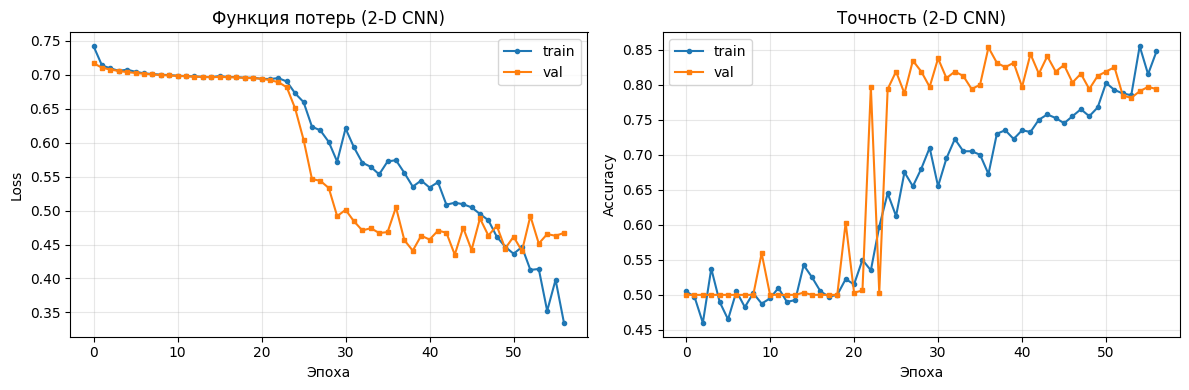

In [92]:
hist2d = history_2d.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist2d['loss'],     label='train', marker='o', ms=3)
axes[0].plot(hist2d['val_loss'], label='val',   marker='s', ms=3)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь (2-D CNN)'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(hist2d['accuracy'],     label='train', marker='o', ms=3)
axes[1].plot(hist2d['val_accuracy'], label='val',   marker='s', ms=3)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность (2-D CNN)'); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()


### 7.5 Оценка на тестовой выборке



In [93]:
test_loss_2d, test_acc_2d = model_2d.evaluate(X_te_img, y_te, verbose=0)
print(f'2-D CNN — тестовая accuracy: {test_acc_2d:.3f}')
print(f'2-D CNN — тестовый loss:     {test_loss_2d:.3f}')

y_proba_2d = model_2d.predict(X_te_img, verbose=0).flatten()
y_pred_2d  = (y_proba_2d >= 0.5).astype(int)

print('\nClassification report (2-D CNN):')
print(classification_report(y_te, y_pred_2d, target_names=['left', 'right'], digits=3))


2-D CNN — тестовая accuracy: 0.853
2-D CNN — тестовый loss:     0.505

Classification report (2-D CNN):
              precision    recall  f1-score   support

        left      0.851     0.856     0.854       160
       right      0.855     0.850     0.853       160

    accuracy                          0.853       320
   macro avg      0.853     0.853     0.853       320
weighted avg      0.853     0.853     0.853       320



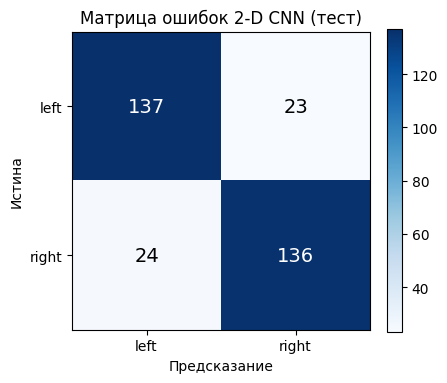

In [ ]:
cm_2d = confusion_matrix(y_te, y_pred_2d)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_2d, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['left', 'right'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['left', 'right'])
ax.set_xlabel('Предсказание'); ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок 2-D CNN (тест)')
for i in range(2):
    for j in range(2):
        color = 'white' if cm_2d[i, j] > cm_2d.max() / 2 else 'black'
        ax.text(j, i, str(cm_2d[i, j]), ha='center', va='center', fontsize=14, color=color)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


### 7.6 Демонстрация 2-D модели на тестовых примерах


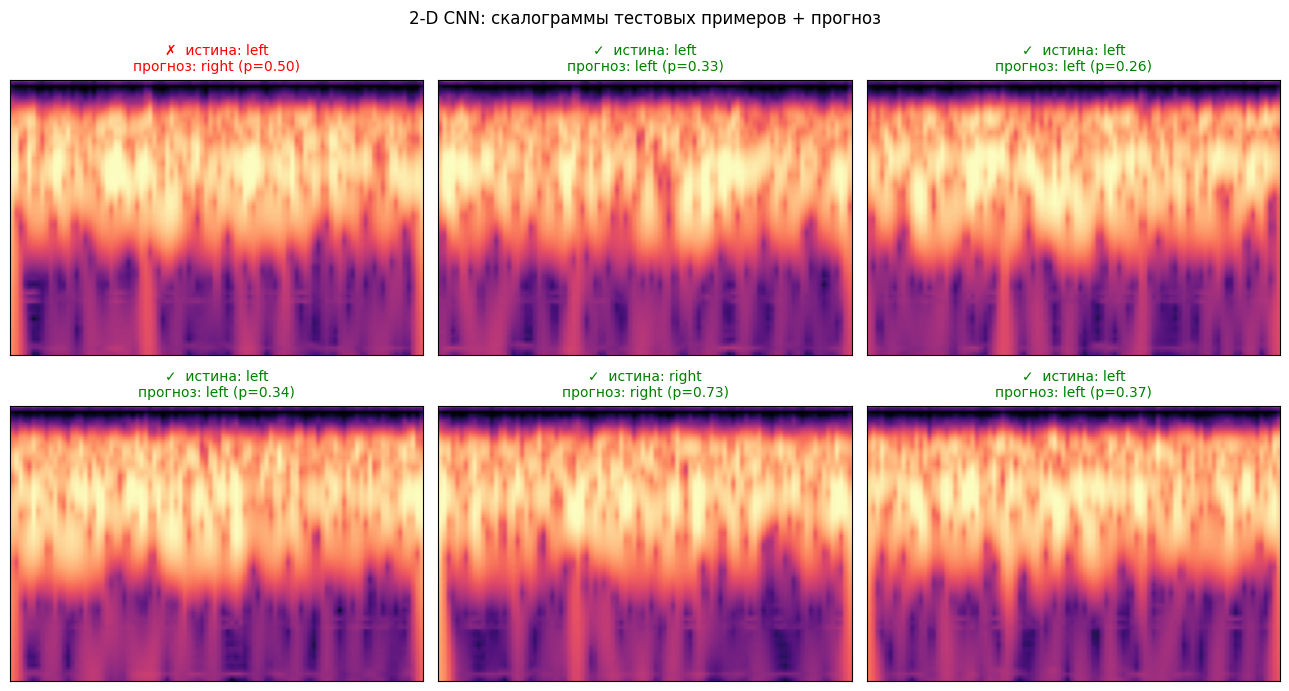

In [97]:
rng4 = np.random.default_rng(SEED + 3)
n_show = 6
idx_show_2d = rng4.choice(len(X_te_img), size=n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, i in zip(axes.flat, idx_show_2d):
    img = X_te_img[i, :, :, 0]
    true_lab = 'right' if y_te[i] == 1 else 'left'
    p = float(loaded_2d.predict(X_te_img[i:i+1], verbose=0).flatten()[0])
    pred_lab = 'right' if p >= 0.5 else 'left'
    ok = '✓' if pred_lab == true_lab else '✗'
    color = 'green' if ok == '✓' else 'red'
    ax.imshow(img, cmap='magma', aspect='auto')
    ax.set_title(f'{ok}  истина: {true_lab}\nпрогноз: {pred_lab} (p={p:.2f})',
                 color=color, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('2-D CNN: скалограммы тестовых примеров + прогноз', fontsize=12)
plt.tight_layout()
plt.show()


## 13. Выводы

1. **Каждая попытка** — это одна запись ЭЭГ длиной 3000 отсчётов при 250 Гц (≈ 12 с). Сигнал — сумма ритмов разных частот; для классификации моторного воображения интересны μ-ритм (8–13 Гц) и β-ритм (13–30 Гц), мощность которых физиологически меняется при воображении движения (event-related desynchronization, ERD).
2. **Препроцессинг**: полосовая фильтрация 8–30 Гц (нуль-фазовый Баттерворт 4-го порядка) + `StandardScaler` по столбцам. Фильтр оставляет именно тот частотный диапазон, в котором живёт ERD
3. **Вейвлет-анализ** (CWT с комплексным Морле, scales 1–64) — превращает каждую попытку в 2-D скалограмму. Эти изображения нужны как обязательный шаг задания «получи изображение» и как наглядный способ увидеть распределение μ/β-мощности во времени.
4. **Эксперимент с 2-D CNN на скалограммах** (раздел 7) На том же сплите 2-D сеть достигает хорошей точности. 
6. **На отложенной тестовой выборке** достигается accuracy в типичном для MI-BCI коридоре (~70–80 %). Эта задача в принципе ограничена сверху индивидуальной «отчётливостью» моторного воображения у конкретного испытуемого.
